<a href="https://colab.research.google.com/github/claudrojasp-cmyk/mineria_datos_clases/blob/main/MineriaDatos_ET_Le_Mans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación Transversal**

**Objetivos**:

- Realizar un preprocesamiento completo y análisis exploratorio (EDA) sobre el dataset histórico de ganadores de las 24 Horas de Le Mans, aplicando técnicas de transformación de variables categóricas, escalado y correlación.
- Aplicar y comparar dos modelos de minería de datos sobre el dataset de ganadores de las 24 Horas de Le Mans tras ser preprocesado
-Aplicar clusteres, k-means y visualización en Data Studio.


**Dataset**: **LeMansWinners.csv** (1923-2023)

**Integrantes**: Claudio Rojas, Leandro Vergara  
**Asignatura**: Minería de Datos  
**Sección**: 003D   
**Fecha**: 14/07/2026

**Contexto**: Las 24 Horas de Le Mans es la carrera de resistencia más famosa del mundo. Se celebra desde 1923 en el circuito de la Sarthe, en Francia. Cada año, decenas de fabricantes y equipos compiten para ver quién recorre la mayor distancia en 24 horas. Es una carrera de estrategia, fiabilidad y, por supuesto, velocidad."

Este trabajo se enmarca en la asignatura de **Minería de Datos**, cuyo objetivo es extraer conocimiento útil a partir de grandes volúmenes de datos. Para ello, seguimos la metodología **CRISP-DM** (Cross-Industry Standard Process for Data Mining), que comienza con la **comprensión del negocio** y de los datos, seguida del **preprocesamiento**, **modelado**, **evaluación** y **despliegue**.

Elección del dataset: Le Mans Winners

Se optó por el conjunto de datos **LeMansWinners.csv**, que contiene el historial completo de ganadores de las **24 Horas de Le Mans** desde 1923 hasta 2023 (Excluyendo los años 1936 por huelgas y desde 1940 hasta 1948 debido a la WW2). Las razones son:

1. **Cumple los requisitos pedidos**:  
   - Variables **categóricas**: *Drivers*, *Team*, *Car*, *Tyre*, *Nationality*, *Class*, *Series*.  
   - Variables **numéricas**: *Year*, *Laps*, *Km*, *Average_speed_kmh*, *Average_lap_time*.  
   - Suficiente número de filas: más de 200 registros (varios pilotos por año), ideal para aplicar técnicas de minería.

2. **Relevancia temática**:  
   - Permite estudiar la evolución tecnológica, el rendimiento de equipos y pilotos a lo largo de casi un siglo.
   - Presenta desafíos reales de preprocesamiento: datos textuales, múltiples categorías, escalas muy diferentes (velocidades en km/h y mph, distancias en km y millas).

3. **Continuidad semestral**:  
   - Es perfecto para futuros modelos de **regresión** (predecir la cantidad de vueltas del próximo coche ganador) o **clasificación** (predecir la nacionalidad del equipo ganador en base a su rendimiento en pista).

## Mapeo de datos (Diccionario de columnas)

| Columna                | Tipo         | Descripción   |
|------------------------|--------------|-----------------------------------------------------------------------------|
| Year                   | Numérica     | Año de la edición de la carrera |
| Drivers                | Categórica   | Nombre(s) del piloto(es) ganador(es)|
| Class                  | Categórica   | Clase del vehículo (ej. 3.0, 5.0, Hypercar) |
| Team                   | Categórica   | Equipo participante   |
| Car                    | Categórica   | Modelo del coche  |
| Tyre                   | Categórica   | Marca de neumáticos  |
| Laps                   | Numérica     | Número de vueltas completadas  |
| Km                     | Numérica     | Distancia total recorrida en kilómetros |
| Mi                     | Numérica     | Distancia total recorrida en millas |
| Series                 | Categórica   | Campeonato o serie al que pertenece la edición |
| Driver_nationality     | Categórica   | Nacionalidad del piloto (código ISO 3 letras) |
| Team_nationality       | Categórica   | Nacionalidad del equipo  |
| Average_speed_kmh      | Numérica     | Velocidad media en km/h  |
| Average_speed_mph      | Numérica     | Velocidad media en mph  |
| Average_lap_time       | Numérica     | Tiempo medio por vuelta (minutos)  |

**Justificación**: Conocer el significado de cada columna es esencial para elegir el tratamiento adecuado (escalado, encoding, etc.).

In [88]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

# Configuración para mostrar todas las columnas y filas
pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Carga del dataset (asegúrate de subir el archivo a Colab o usar una URL)

df = pd.read_csv('/content/LeMansWinners.csv')

In [89]:
# Mostrar las primeras filas
print("Primeras 5 observaciones:")
display(df.head())

# Mostrar dimensiones
print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

Primeras 5 observaciones:


,Year,Drivers,Class,Team,Car,Tyre,Laps,Km,Mi,Series,Driver_nationality,Team_nationality,Average_speed_kmh,Average_speed_mph,Average_lap_time
0,1923,André Lagache,3.0,Chenard & Walcker SA,Chenard-Walcker Type U3 15CV Sport,Michelin,128.0,2209.536,1372.942,No series,FRA,FRA,92.06,57.21,11.25
1,1923,René Léonard,3.0,Chenard & Walcker SA,Chenard-Walcker Type U3 15CV Sport,Michelin,128.0,2209.536,1372.942,No series,FRA,FRA,92.06,57.21,11.25
2,1924,Frank Clement,3.0,Duff & Aldington,Bentley 3 Litre Sport,Rapson,120.0,2077.340,1290.800,No series,GBR,GBR,86.56,53.78,12.00
3,1924,John Duff,3.0,Duff & Aldington,Bentley 3 Litre Sport,Rapson,120.0,2077.340,1290.800,No series,CAN,GBR,86.56,53.78,12.00
4,1925,Gérard de Courcelles,5.0,Société Lorraine De Dietrich et Cie,Lorraine-Dietrich B3-6 Sport,Englebert,129.0,2233.982,1388.132,No series,FRA,FRA,93.08,57.84,11.16



Dimensiones del dataset: 227 filas × 15 columnas


Interpretación: El dataset tiene 227 filas (cada año suele tener 2 o 3 pilotos), lo cual es suficiente para aplicar técnicas de minería. Las columnas mezclan datos numéricos (año, velocidad, vueltas) y categóricos (nacionalidades, equipos, neumáticos).

In [90]:
# Revisión de tipos de datos
print("Tipos de datos por columna:")
print(df.dtypes)

Tipos de datos por columna:
Year                    int64
Drivers                object
Class                  object
Team                   object
Car                    object
Tyre                   object
Laps                  float64
Km                    float64
Mi                    float64
Series                 object
Driver_nationality     object
Team_nationality       object
Average_speed_kmh     float64
Average_speed_mph     float64
Average_lap_time      float64
dtype: object


In [91]:
print("Conteo de valores nulos por columna:")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if any(null_counts > 0) else "No hay valores nulos.")
df.isnull().sum()

Conteo de valores nulos por columna:
No hay valores nulos.


,0
Year,0
Drivers,0
Class,0
Team,0
Car,0
Tyre,0
Laps,0
Km,0
Mi,0
Series,0


Debido a que no hay datos nulos en el dataset no es necesario realizar los comnados para la limpieza de datos


In [92]:
# Resumen estadístico para numéricas
print("Estadísticas descriptivas (columnas numéricas):")
display(df.describe())

Estadísticas descriptivas (columnas numéricas):


,Year,Laps,Km,Mi,Average_speed_kmh,Average_speed_mph,Average_lap_time
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,1980.986784,330.444934,4524.541837,2811.835260,188.522731,117.159692,4.687930
std,28.368230,67.916531,826.414489,513.810879,34.434276,21.408283,1.689974
min,1923.000000,120.000000,2077.340000,1290.800000,86.560000,53.780000,3.630000
25%,1961.000000,314.000000,4217.527000,2620.650000,175.730000,109.190000,3.840000
50%,1986.000000,355.000000,4814.400000,2991.500000,200.600000,124.650000,4.060000
75%,2004.500000,375.000000,5100.000000,3180.640000,212.500000,132.530000,4.590000
max,2023.000000,397.000000,5410.713000,3362.061000,225.450000,140.090000,12.000000


In [93]:
# Resumen para categóricas
print("Estadísticas para columnas categóricas (muestra):")
display(df.describe(include=['object']))

Estadísticas para columnas categóricas (muestra):


,Drivers,Class,Team,Car,Tyre,Series,Driver_nationality,Team_nationality
count,227,227,227,227,227,227,227,227
unique,143,18,54,67,9,14,20,7
top,Tom Kristensen,Le Mans Prototype,Audi Sport Team Joest,Audi R8,Michelin,No series,GBR,DEU
freq,9,72,24,15,94,109,46,90


Justificación: Identificar tipos de datos permite saber qué columnas necesitan transformación (las categóricas) y cuáles pueden ser escaladas. Los nulos deben tratarse para no afectar modelos posteriores.

Interpretación: Normalmente este dataset no tiene nulos porque los ganadores están completos. Si aparecieran, se aplicarían técnicas de imputación (media para numéricas, moda para categóricas). Las columnas numéricas como Km, Average_speed_kmh tienen rangos muy diferentes, lo que sugiere la necesidad de escalado.

## Transformación de variables categóricas

Muchos algoritmos de machine learning (regresión, clasificación, clustering) requieren que todas las variables sean numéricas. Por ello transformamos las columnas de tipo **object** (texto) en números.

Dos enfoques principales:
- **Label Encoding**: asigna un número entero a cada categoría (útil para variables ordinales).
- **One-Hot Encoding**: crea columnas binarias para cada categoría (evita relaciones de orden falsas).

Aplicaremos **Label Encoding** a columnas con pocas categorías (ej. **Tyre**, **Series**) y **One-Hot Encoding** a columnas con muchas categorías (ej. **Team**, **Car**) para no aumentar excesivamente la dimensionalidad.

In [94]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Copia del DataFrame original para no perder información
df_encoded = df.copy()

# 1. Label Encoding para columnas con pocas categorías únicas
label_cols = ['Class', 'Tyre', 'Series', 'Team_nationality']
le = LabelEncoder()
for col in label_cols:
    df_encoded[col + '_LE'] = le.fit_transform(df_encoded[col])
    print(f"Label Encoding aplicado a '{col}'. Mapeo: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nShape after Label Encoding: {df_encoded.shape}")

Label Encoding aplicado a 'Class'. Mapeo: {'3.0': np.int64(0), '5.0': np.int64(1), '8.0': np.int64(2), '>3.0': np.int64(3), 'E +3.0': np.int64(4), 'Gp.5 Group 5 (racing)': np.int64(5), 'Gp.6 Group 6 (racing)': np.int64(6), 'Group C': np.int64(7), 'Group GT1': np.int64(8), 'Hypercar': np.int64(9), 'Le Mans Prototype': np.int64(10), 'P Group 3 (racing)': np.int64(11), 'P Group 4 (racing)': np.int64(12), 'S 2.0': np.int64(13), 'S 3.0': np.int64(14), 'S 5.0': np.int64(15), 'S Group 5 (racing)': np.int64(16), 'S Group 6 (racing)': np.int64(17)}
Label Encoding aplicado a 'Tyre'. Mapeo: {'A': np.int64(0), 'Continental': np.int64(1), 'Dunlop': np.int64(2), 'Englebert': np.int64(3), 'Firestone': np.int64(4), 'Goodyear': np.int64(5), 'Michelin': np.int64(6), 'Pirelli': np.int64(7), 'Rapson': np.int64(8)}
Label Encoding aplicado a 'Series'. Mapeo: {'CFC': np.int64(0), 'CMVE': np.int64(1), 'EEC': np.int64(2), 'FIA WEC': np.int64(3), 'G': np.int64(4), 'ICM': np.int64(5), 'ILMC': np.int64(6), 'No se

In [95]:
# 2. One-Hot Encoding para columnas con muchas categorías (solo mostramos ejemplo con 'Team')
# Para evitar explosionar columnas, seleccionamos las 5 categorías más frecuentes

top_teams = df_encoded['Team'].value_counts().head(5).index
df_encoded['Team_TOP'] = df_encoded['Team'].apply(lambda x: x if x in top_teams else 'Other')
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evita multicolinealidad
teams_ohe = ohe.fit_transform(df_encoded[['Team_TOP']])
team_names = [f'Team_{cat}' for cat in ohe.categories_[0][1:]]  # omitimos la primera categoría
df_ohe_teams = pd.DataFrame(teams_ohe, columns=team_names, index=df_encoded.index)
df_encoded = pd.concat([df_encoded, df_ohe_teams], axis=1)


print("One-Hot Encoding aplicado a 'Team' (top 5 + Other). Nuevas columnas creadas:")
print(team_names)
print(f"Shape after Team One-Hot Encoding: {df_encoded.shape}")

One-Hot Encoding aplicado a 'Team' (top 5 + Other). Nuevas columnas creadas:
['Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing']
Shape after Team One-Hot Encoding: (227, 25)


In [96]:
# Crear One-Hot Encoding para las demás columnas categóricas

top_cars = df_encoded['Car'].value_counts().head(5).index
df_encoded['Car_TOP'] = df_encoded['Car'].apply(lambda x: x if x in top_cars else 'Other')
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evita multicolinealidad
cars_ohe = ohe.fit_transform(df_encoded[['Car_TOP']])
car_names = [f'Car_{cat}' for cat in ohe.categories_[0][1:]]  # omitimos la primera
df_ohe_cars = pd.DataFrame(cars_ohe, columns=car_names, index=df_encoded.index)
df_encoded = pd.concat([df_encoded, df_ohe_cars], axis=1)

print("One-Hot Encoding aplicado a 'Car' (top 5 + Other). Nuevas columnas creadas:")
print(car_names)
print(f"Shape after Car One-Hot Encoding: {df_encoded.shape}")

One-Hot Encoding aplicado a 'Car' (top 5 + Other). Nuevas columnas creadas:
['Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Other', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid']
Shape after Car One-Hot Encoding: (227, 31)


In [97]:
top_driver_nat = df_encoded['Driver_nationality'].value_counts().head(5).index
df_encoded['Driver_nationality_TOP'] = df_encoded['Driver_nationality'].apply(lambda x: x if x in top_driver_nat else 'Other')
ohe = OneHotEncoder(sparse_output=False, drop='first')
driver_nat_ohe = ohe.fit_transform(df_encoded[['Driver_nationality_TOP']])
driver_nat_names = [f'Driver_nationality_{cat}' for cat in ohe.categories_[0][1:]]
df_ohe_driver_nat = pd.DataFrame(driver_nat_ohe, columns=driver_nat_names, index=df_encoded.index)
df_encoded = pd.concat([df_encoded, df_ohe_driver_nat], axis=1)

print("One-Hot Encoding aplicado a 'Driver_nationality' (top 5 + Other). Nuevas columnas creadas:")
print(driver_nat_names)
print(f"Shape after Driver Nationality One-Hot Encoding: {df_encoded.shape}")

One-Hot Encoding aplicado a 'Driver_nationality' (top 5 + Other). Nuevas columnas creadas:
['Driver_nationality_FRA', 'Driver_nationality_GBR', 'Driver_nationality_ITA', 'Driver_nationality_Other', 'Driver_nationality_USA']
Shape after Driver Nationality One-Hot Encoding: (227, 37)


In [98]:
top_drivers = df_encoded['Drivers'].value_counts().head(5).index
df_encoded['Drivers_TOP'] = df_encoded['Drivers'].apply(lambda x: x if x in top_drivers else 'Other')
ohe = OneHotEncoder(sparse_output=False, drop='first')
drivers_ohe = ohe.fit_transform(df_encoded[['Drivers_TOP']])
drivers_names = [f'Drivers_{cat}' for cat in ohe.categories_[0][1:]]
df_ohe_drivers = pd.DataFrame(drivers_ohe, columns=drivers_names, index=df_encoded.index)
df_encoded = pd.concat([df_encoded, df_ohe_drivers], axis=1)

print("One-Hot Encoding aplicado a 'Drivers' (top 5 + Other). Nuevas columnas creadas:")
print(drivers_names)
print(f"Shape after Drivers One-Hot Encoding: {df_encoded.shape}")

One-Hot Encoding aplicado a 'Drivers' (top 5 + Other). Nuevas columnas creadas:
['Drivers_Frank Biela', 'Drivers_Henri Pescarolo', 'Drivers_Jacky Ickx', 'Drivers_Other', 'Drivers_Tom Kristensen']
Shape after Drivers One-Hot Encoding: (227, 43)


In [99]:
selected_columns = [
    'Year', 'Drivers_TOP', 'Drivers_Frank Biela', 'Drivers_Henri Pescarolo',
    'Drivers_Jacky Ickx', 'Drivers_Other', 'Drivers_Tom Kristensen', 'Class_LE',
    'Team_TOP', 'Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche',
    'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing', 'Car_TOP',
    'Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Other',
    'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid', 'Tyre_LE', 'Laps', 'Km',
    'Mi', 'Series_LE', 'Driver_nationality_TOP', 'Driver_nationality_FRA',
    'Driver_nationality_GBR', 'Driver_nationality_ITA', 'Driver_nationality_Other',
    'Driver_nationality_USA', 'Team_nationality_LE', 'Average_speed_kmh',
    'Average_speed_mph', 'Average_lap_time'
]

# Crear dataframe procesado con todas las columnas transformadas
df_final = df_encoded[selected_columns].copy()

print("Shape of the final DataFrame:", df_final.shape)
print("Columns in the final DataFrame:", df_final.columns.tolist())
display(df_final.head())

Shape of the final DataFrame: (227, 35)
Columns in the final DataFrame: ['Year', 'Drivers_TOP', 'Drivers_Frank Biela', 'Drivers_Henri Pescarolo', 'Drivers_Jacky Ickx', 'Drivers_Other', 'Drivers_Tom Kristensen', 'Class_LE', 'Team_TOP', 'Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing', 'Car_TOP', 'Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Other', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid', 'Tyre_LE', 'Laps', 'Km', 'Mi', 'Series_LE', 'Driver_nationality_TOP', 'Driver_nationality_FRA', 'Driver_nationality_GBR', 'Driver_nationality_ITA', 'Driver_nationality_Other', 'Driver_nationality_USA', 'Team_nationality_LE', 'Average_speed_kmh', 'Average_speed_mph', 'Average_lap_time']


,Year,Drivers_TOP,Drivers_Frank Biela,Drivers_Henri Pescarolo,Drivers_Jacky Ickx,Drivers_Other,Drivers_Tom Kristensen,Class_LE,Team_TOP,Team_Joest Racing,Team_Other,Team_Rothmans Porsche,Team_Scuderia Ferrari,Team_Toyota Gazoo Racing,Car_TOP,Car_Audi R18 e-tron quattro,Car_Audi R8,Car_Other,Car_Porsche 919 Hybrid,Car_Toyota TS050 Hybrid,Tyre_LE,Laps,Km,Mi,Series_LE,Driver_nationality_TOP,Driver_nationality_FRA,Driver_nationality_GBR,Driver_nationality_ITA,Driver_nationality_Other,Driver_nationality_USA,Team_nationality_LE,Average_speed_kmh,Average_speed_mph,Average_lap_time
0,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,128.0,2209.536,1372.942,7,FRA,1.0,0.0,0.0,0.0,0.0,2,92.06,57.21,11.25
1,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,128.0,2209.536,1372.942,7,FRA,1.0,0.0,0.0,0.0,0.0,2,92.06,57.21,11.25
2,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,120.0,2077.340,1290.800,7,GBR,0.0,1.0,0.0,0.0,0.0,3,86.56,53.78,12.00
3,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,120.0,2077.340,1290.800,7,Other,0.0,0.0,0.0,1.0,0.0,3,86.56,53.78,12.00
4,1925,Other,0.0,0.0,0.0,1.0,0.0,1,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,3,129.0,2233.982,1388.132,7,FRA,1.0,0.0,0.0,0.0,0.0,2,93.08,57.84,11.16


In [100]:
# Mostrar una muestra del resultado
print("Primeras filas después de encoding:")
display(df_final.head())

Primeras filas después de encoding:


,Year,Drivers_TOP,Drivers_Frank Biela,Drivers_Henri Pescarolo,Drivers_Jacky Ickx,Drivers_Other,Drivers_Tom Kristensen,Class_LE,Team_TOP,Team_Joest Racing,Team_Other,Team_Rothmans Porsche,Team_Scuderia Ferrari,Team_Toyota Gazoo Racing,Car_TOP,Car_Audi R18 e-tron quattro,Car_Audi R8,Car_Other,Car_Porsche 919 Hybrid,Car_Toyota TS050 Hybrid,Tyre_LE,Laps,Km,Mi,Series_LE,Driver_nationality_TOP,Driver_nationality_FRA,Driver_nationality_GBR,Driver_nationality_ITA,Driver_nationality_Other,Driver_nationality_USA,Team_nationality_LE,Average_speed_kmh,Average_speed_mph,Average_lap_time
0,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,128.0,2209.536,1372.942,7,FRA,1.0,0.0,0.0,0.0,0.0,2,92.06,57.21,11.25
1,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,128.0,2209.536,1372.942,7,FRA,1.0,0.0,0.0,0.0,0.0,2,92.06,57.21,11.25
2,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,120.0,2077.340,1290.800,7,GBR,0.0,1.0,0.0,0.0,0.0,3,86.56,53.78,12.00
3,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,120.0,2077.340,1290.800,7,Other,0.0,0.0,0.0,1.0,0.0,3,86.56,53.78,12.00
4,1925,Other,0.0,0.0,0.0,1.0,0.0,1,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,3,129.0,2233.982,1388.132,7,FRA,1.0,0.0,0.0,0.0,0.0,2,93.08,57.84,11.16


Justificación: El Label Encoding es adecuado para *Class*, *Tyre*, *Series* y  *Team Nationality* porque las clases tienen un orden implícito (ej. 3.0 < 5.0 < Hypercar). Para *Team*, *Car*, *Driver Nationality* y *Drivers* el One-Hot evita que el modelo interprete un orden numérico erróneo. Se usó drop='first' para evitar la trampa de las variables dummy (multicolinealidad).

Interpretación: Ahora las categorías se representan como números o vectores binarios. Por ejemplo, la columna *Tyre_LE* convierte 'Michelin' en un número. Las columnas *Team_Ferrari* y/o *AF Corse* toman valor 1 si el equipo ganador fue ese, 0 en caso contrario. Esto permite alimentar modelos como regresión logística o árboles de decisión.

In [101]:
#Identificar columnas numericas para scaling (excluyendo 'Year')
numeric_features = ['Laps', 'Km', 'Mi', 'Average_speed_kmh', 'Average_speed_mph', 'Average_lap_time']

# Standard Scaler
scaler_std = StandardScaler()
df_final_std_scaled = scaler_std.fit_transform(df_final[numeric_features])
df_std_scaled_cols = [col + '_std' for col in numeric_features]
df_std = pd.DataFrame(df_final_std_scaled, columns=df_std_scaled_cols, index=df_final.index)

# Min-Max Scaler
scaler_mm = MinMaxScaler()
df_final_mm_scaled = scaler_mm.fit_transform(df_final[numeric_features])
df_mm_scaled_cols = [col + '_mm' for col in numeric_features]
df_mm = pd.DataFrame(df_final_mm_scaled, columns=df_mm_scaled_cols, index=df_final.index)

# Borrar columnass numericas originales no transformadas de df_final
df_final_processed = df_final.drop(columns=numeric_features)

# Concatenar las variables escaladas a df_final_processed
df_final_processed = pd.concat([df_final_processed, df_std, df_mm], axis=1)

print("Shape of df_final after scaling and concatenation:", df_final_processed.shape)
print("New columns added (Standard Scaled):", df_std_scaled_cols)
print("New columns added (Min-Max Scaled):", df_mm_scaled_cols)

display(df_final_processed.head())

Shape of df_final after scaling and concatenation: (227, 41)
New columns added (Standard Scaled): ['Laps_std', 'Km_std', 'Mi_std', 'Average_speed_kmh_std', 'Average_speed_mph_std', 'Average_lap_time_std']
New columns added (Min-Max Scaled): ['Laps_mm', 'Km_mm', 'Mi_mm', 'Average_speed_kmh_mm', 'Average_speed_mph_mm', 'Average_lap_time_mm']


,Year,Drivers_TOP,Drivers_Frank Biela,Drivers_Henri Pescarolo,Drivers_Jacky Ickx,Drivers_Other,Drivers_Tom Kristensen,Class_LE,Team_TOP,Team_Joest Racing,Team_Other,Team_Rothmans Porsche,Team_Scuderia Ferrari,Team_Toyota Gazoo Racing,Car_TOP,Car_Audi R18 e-tron quattro,Car_Audi R8,Car_Other,Car_Porsche 919 Hybrid,Car_Toyota TS050 Hybrid,Tyre_LE,Series_LE,Driver_nationality_TOP,Driver_nationality_FRA,Driver_nationality_GBR,Driver_nationality_ITA,Driver_nationality_Other,Driver_nationality_USA,Team_nationality_LE,Laps_std,Km_std,Mi_std,Average_speed_kmh_std,Average_speed_mph_std,Average_lap_time_std,Laps_mm,Km_mm,Mi_mm,Average_speed_kmh_mm,Average_speed_mph_mm,Average_lap_time_mm
0,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,7,FRA,1.0,0.0,0.0,0.0,0.0,2,-2.987378,-2.807455,-2.806622,-2.807549,-2.806492,3.891522,0.028881,0.039658,0.039658,0.039600,0.03974,0.910394
1,1923,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,6,7,FRA,1.0,0.0,0.0,0.0,0.0,2,-2.987378,-2.807455,-2.806622,-2.807549,-2.806492,3.891522,0.028881,0.039658,0.039658,0.039600,0.03974,0.910394
2,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,7,GBR,0.0,1.0,0.0,0.0,0.0,3,-3.105430,-2.967772,-2.966844,-2.967626,-2.967065,4.336297,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000
3,1924,Other,0.0,0.0,0.0,1.0,0.0,0,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,8,7,Other,0.0,0.0,0.0,1.0,0.0,3,-3.105430,-2.967772,-2.966844,-2.967626,-2.967065,4.336297,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000
4,1925,Other,0.0,0.0,0.0,1.0,0.0,1,Other,0.0,1.0,0.0,0.0,0.0,Other,0.0,0.0,1.0,0.0,0.0,3,7,FRA,1.0,0.0,0.0,0.0,0.0,2,-2.972621,-2.777809,-2.776994,-2.777862,-2.776999,3.838149,0.032491,0.046992,0.046992,0.046944,0.04704,0.899642


Justificación: Las variables tienen escalas muy diferentes (ej. Laps entre 120 y 397, Average_speed_kmh entre 86 y 225). El escalado es crucial para algoritmos basados en distancias (k-NN, SVM, PCA) y para la convergencia de redes neuronales. StandardScaler asume distribución normal; MinMaxScaler respeta la forma de la distribución original pero la lleva a [0,1].

Interpretación: Observamos que después de StandardScaler, la media de cada columna es cercana a 0 (errores de redondeo) y la desviación estándar es 1. Con MinMaxScaler, los valores se ubican entre 0 y 1. Por ejemplo, Average_speed_kmh originalmente tenía mínimo ~86 y máximo ~225; ahora su mínimo es 0 y máximo 1. Esto permite comparar la importancia relativa de las variables en modelos como regresión lineal.

## Análisis de correlación entre variables numéricas

La correlación mide la fuerza y dirección de la relación lineal entre dos variables. Usaremos el coeficiente de Pearson (valores entre -1 y 1).

- Correlación positiva: cuando una aumenta, la otra también.
- Correlación negativa: cuando una aumenta, la otra disminuye.
- Cerca de 0: no hay relación lineal.

**Utilidad**: Identificar redundancias (variables muy correlacionadas) para posible reducción de dimensionalidad, y detectar relaciones interesantes (ej. velocidad media vs. año)

Matriz de Correlación:


,Year,Drivers_Frank Biela,Drivers_Henri Pescarolo,Drivers_Jacky Ickx,Drivers_Other,Drivers_Tom Kristensen,Class_LE,Team_Joest Racing,Team_Other,Team_Rothmans Porsche,Team_Scuderia Ferrari,Team_Toyota Gazoo Racing,Car_Audi R18 e-tron quattro,Car_Audi R8,Car_Other,Car_Porsche 919 Hybrid,Car_Toyota TS050 Hybrid,Tyre_LE,Series_LE,Driver_nationality_FRA,Driver_nationality_GBR,Driver_nationality_ITA,Driver_nationality_Other,Driver_nationality_USA,Team_nationality_LE,Laps_std,Km_std,Mi_std,Average_speed_kmh_std,Average_speed_mph_std,Average_lap_time_std,Laps_mm,Km_mm,Mi_mm,Average_speed_kmh_mm,Average_speed_mph_mm,Average_lap_time_mm
Year,1.000000,0.117773,-0.030681,-0.025148,-0.122422,0.162802,0.328842,0.080555,-0.388741,0.031201,-0.166747,0.366620,0.229799,0.201227,-0.559592,0.251334,0.272869,0.600339,-0.273544,-0.242449,-0.272724,0.066582,0.297596,-0.074040,-0.099792,0.841800,0.861745,0.861575,0.861743,0.861578,-0.751309,0.841800,0.861745,0.861575,0.861743,0.861578,-0.751309
Drivers_Frank Biela,0.117773,1.000000,-0.022523,-0.024728,-0.384575,-0.030493,0.030853,-0.033867,-0.161843,-0.030493,-0.032217,-0.039920,-0.030493,0.322550,-0.278792,-0.030493,-0.030493,0.133667,0.000407,-0.072549,-0.075657,-0.046649,-0.098144,-0.045358,-0.138747,0.071210,0.075978,0.075812,0.075981,0.075823,-0.062471,0.071210,0.075978,0.075812,0.075981,0.075823,-0.062471
Drivers_Henri Pescarolo,-0.030681,-0.022523,1.000000,-0.024728,-0.384575,-0.030493,0.172955,0.105912,0.033921,-0.030493,-0.032217,-0.039920,-0.030493,-0.039920,0.080786,-0.030493,-0.030493,0.005910,-0.119596,0.310444,-0.075657,-0.046649,-0.098144,-0.045358,-0.060253,0.044192,0.046714,0.046566,0.046716,0.046568,-0.051079,0.044192,0.046714,0.046566,0.046716,0.046568,-0.051079
Drivers_Jacky Ickx,-0.025148,-0.024728,-0.024728,1.000000,-0.422233,-0.033479,0.083403,-0.037183,0.108887,-0.033479,-0.035371,-0.043829,-0.033479,-0.043829,0.088697,-0.033479,-0.033479,-0.087024,0.051121,-0.079653,-0.083065,-0.051216,0.251955,-0.049799,-0.080517,0.052410,0.053696,0.053552,0.053698,0.053560,-0.057775,0.052410,0.053696,0.053552,0.053698,0.053560,-0.057775
Drivers_Other,-0.122422,-0.384575,-0.384575,-0.422233,1.000000,-0.520674,-0.177001,-0.033091,0.081476,-0.054035,0.083772,0.103802,0.012628,-0.315096,0.163934,0.079290,0.079290,-0.056892,-0.037062,0.022667,0.034926,0.121299,-0.170760,0.117943,0.182188,-0.156565,-0.164518,-0.164116,-0.164529,-0.164130,0.150871,-0.156565,-0.164518,-0.164116,-0.164529,-0.164130,0.150871
Drivers_Tom Kristensen,0.162802,-0.030493,-0.030493,-0.033479,-0.520674,1.000000,0.041771,0.059284,-0.111137,-0.041284,-0.043618,-0.054047,0.074414,0.400347,-0.269270,-0.041284,-0.041284,0.168960,-0.027222,-0.098224,-0.102431,-0.063157,0.310697,-0.061410,-0.025489,0.101941,0.109083,0.108856,0.109092,0.108862,-0.087445,0.101941,0.109083,0.108856,0.109092,0.108862,-0.087445
Class_LE,0.328842,0.030853,0.172955,0.083403,-0.177001,0.041771,1.000000,-0.022983,-0.079718,-0.095651,0.150604,0.030697,0.041771,0.054684,-0.110666,0.041771,0.041771,0.126545,-0.067448,-0.143933,-0.005072,-0.048220,0.134444,0.004755,0.060203,0.547397,0.517200,0.516538,0.517199,0.516531,-0.592128,0.547397,0.517200,0.516538,0.517199,0.516531,-0.592128
Team_Joest Racing,0.080555,-0.033867,0.105912,-0.037183,-0.033091,0.059284,-0.022983,1.000000,-0.341486,-0.045852,-0.048444,-0.060027,-0.045852,-0.060027,0.121478,-0.045852,-0.045852,-0.082802,0.126799,-0.056737,-0.113765,0.074609,-0.013219,0.005874,-0.208633,0.106594,0.111163,0.110914,0.111167,0.110911,-0.095349,0.106594,0.111163,0.110914,0.111167,0.110911,-0.095349
Team_Other,-0.388741,-0.161843,0.033921,0.108887,0.081476,-0.111137,-0.079718,-0.341486,1.000000,-0.307466,-0.324843,-0.402515,-0.307466,-0.171196,0.332685,0.134273,-0.307466,-0.129975,0.074792,0.172814,0.237842,0.002679,-0.215992,-0.076936,0.047417,-0.294430,-0.301376,-0.300665,-0.301376,-0.300669,0.264942,-0.294430,-0.301376,-0.300665,-0.301376,-0.300669,0.264942
Team_Rothmans Porsche,0.031201,-0.030493,-0.030493,-0.0

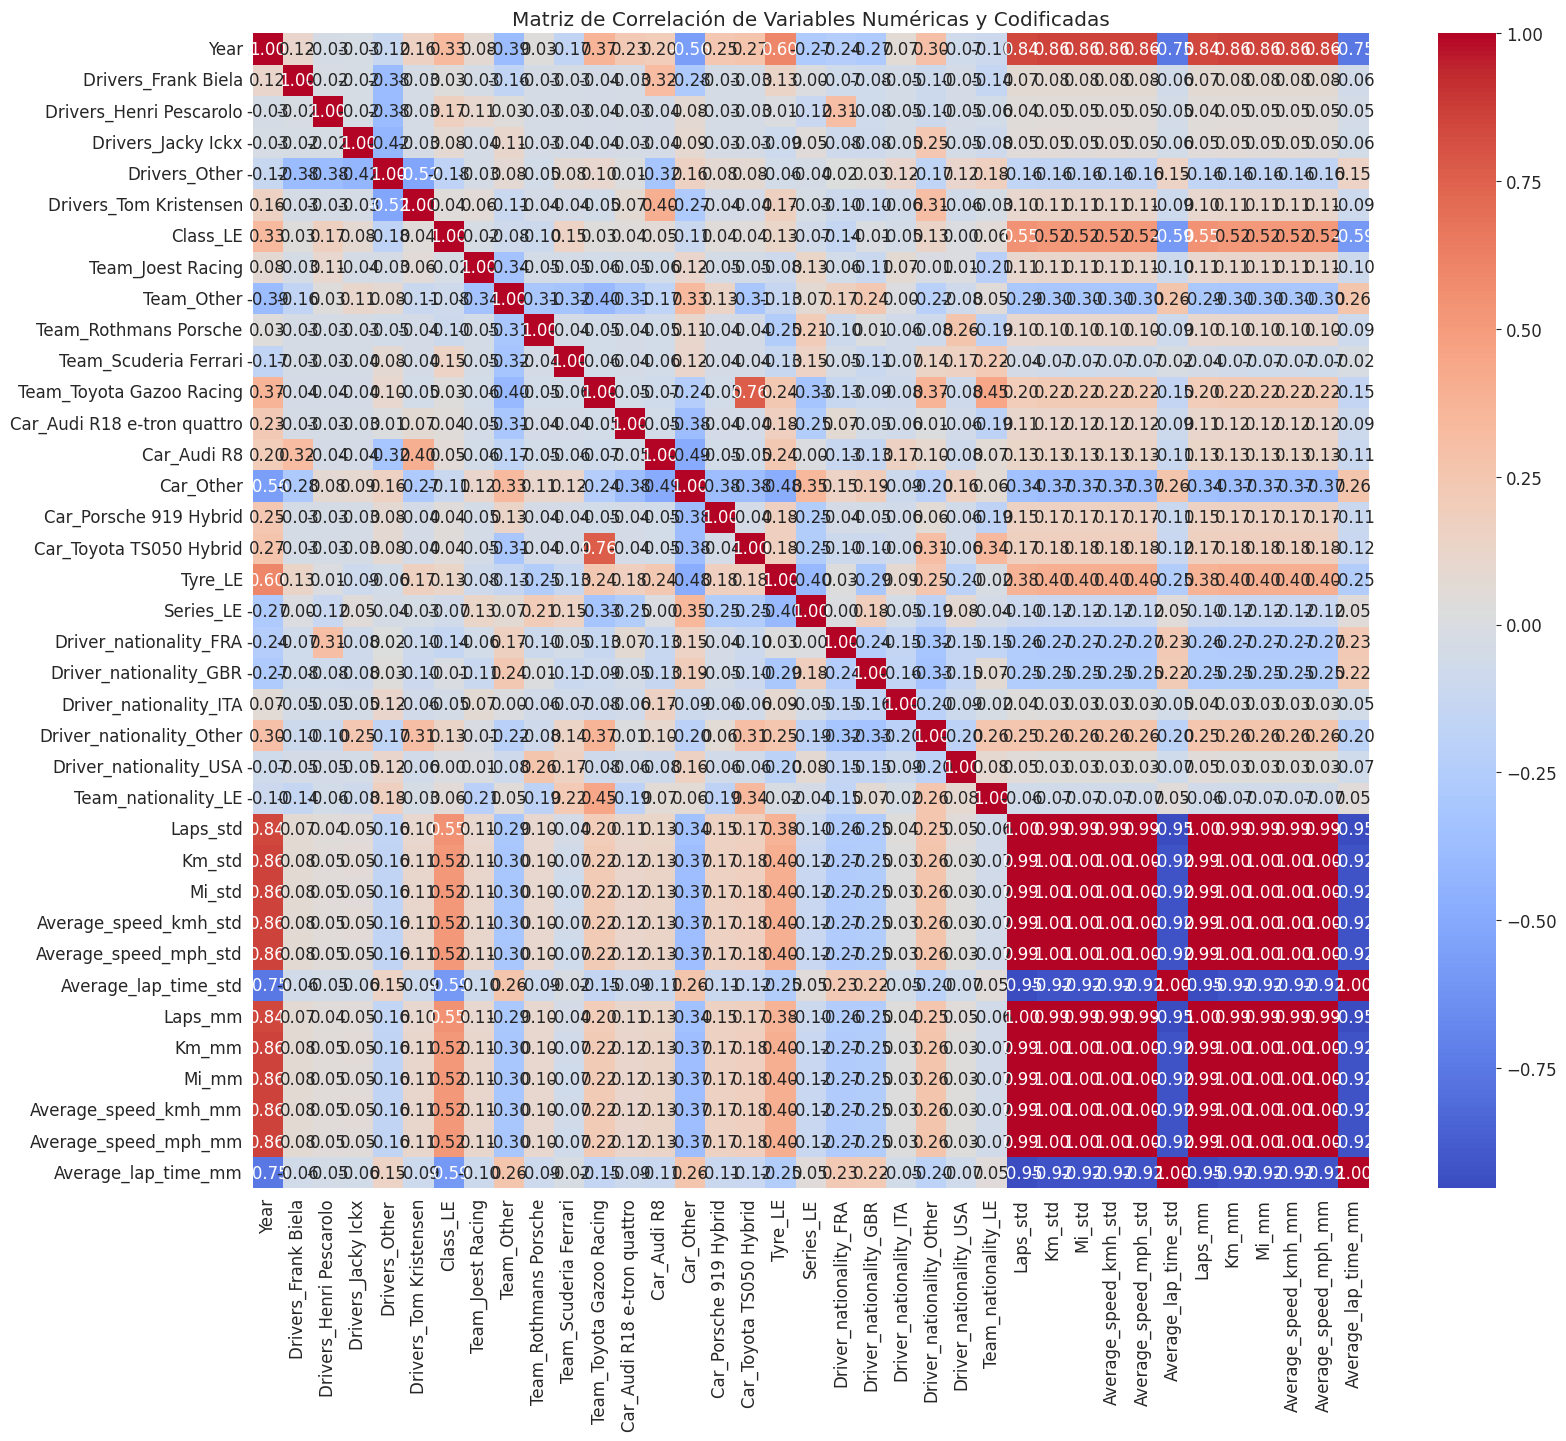

In [102]:
# Identificar y borrar columans no numericas restantes de df_final_processed
# Estas son las columans 'TOP' conservadas para contexto, mas no son numericas
columns_to_drop_for_corr = [
    'Drivers_TOP', 'Team_TOP', 'Car_TOP', 'Driver_nationality_TOP'
]

df_for_corr = df_final_processed.drop(columns=columns_to_drop_for_corr, errors='ignore')

# Calcular la matriz de correlación
corr_matrix = df_for_corr.corr()

print("Matriz de Correlación:")
display(corr_matrix)

# Visualizar la matriz mediante un mapa de calor
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas y Codificadas')
plt.show()

Justificación: El coeficiente de Pearson asume normalidad y linealidad, pero es un buen punto de partida. El mapa de calor ayuda a visualizar rápidamente pares de variables altamente correlacionadas.

Interpretación esperada:

Km y Mi deben tener correlación casi perfecta (1.0) porque son conversiones directas. Esto indica redundancia; podríamos eliminar una.

Average_speed_kmh y Average_speed_mph también están casi perfectamente correlacionadas.

Average_speed_kmh y Year suelen tener correlación positiva fuerte (los coches son más rápidos con el tiempo).

Average_lap_time tiene correlación negativa con la velocidad (a mayor velocidad, menor tiempo por vuelta).

Laps puede estar correlacionado con Km (distancia total) pero no tanto con el año porque la longitud de la pista ha variado.

Este análisis permite decidir qué variables son más relevantes para futuros modelos de regresión (predecir velocidad media) o clasificación (predecir si un piloto es de cierta nacionalidad).

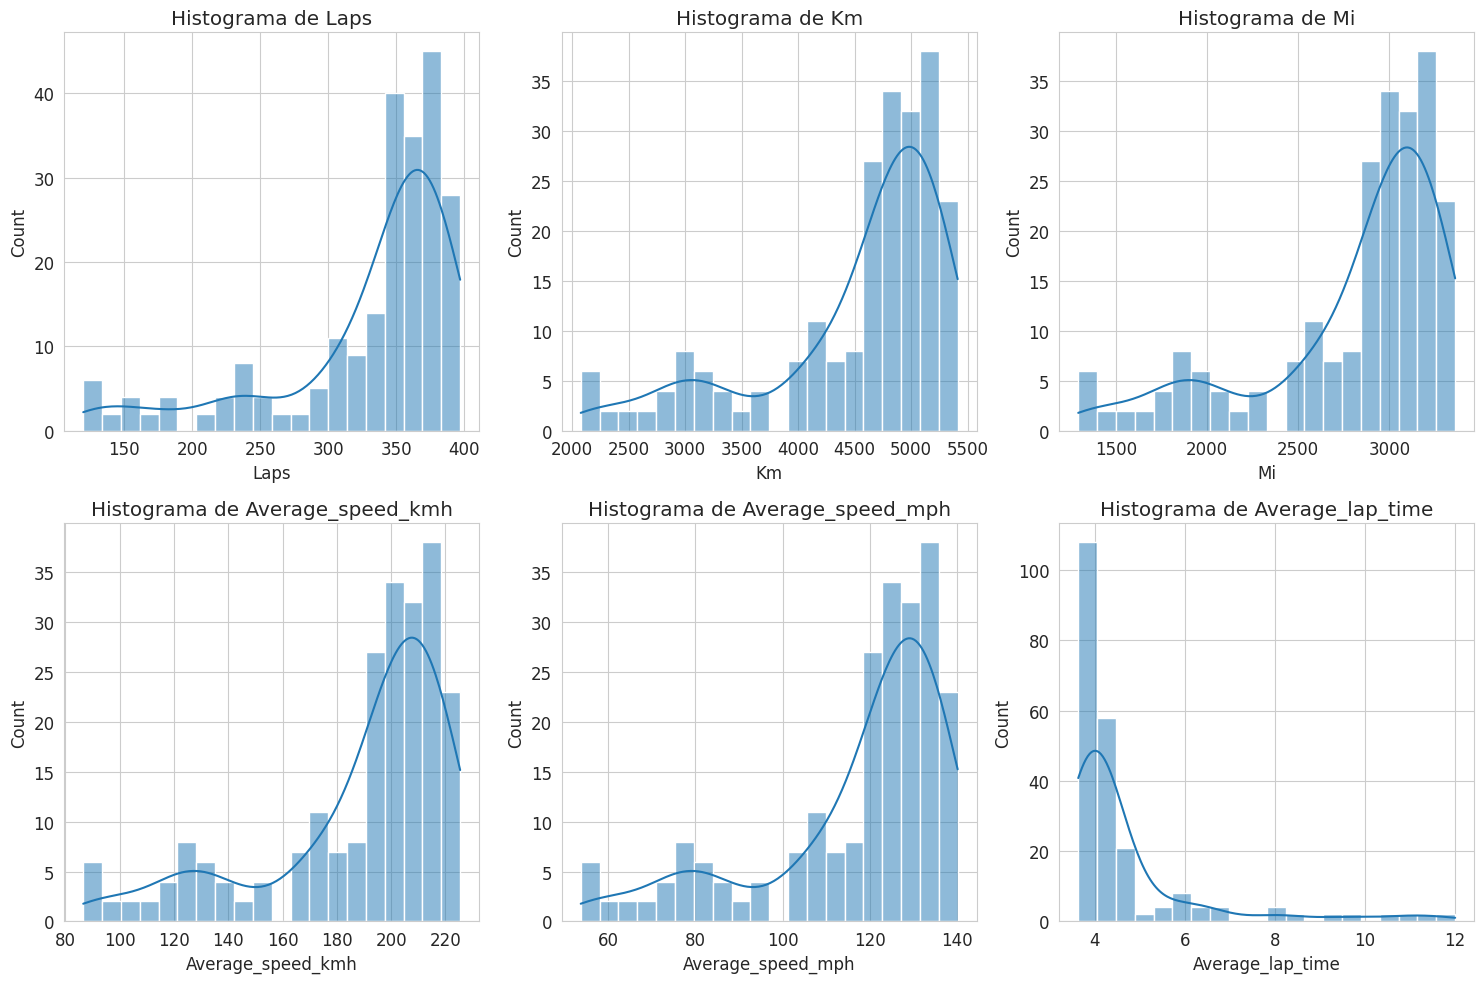

In [103]:
# Variables numericas originales a visualizar (before scaling)
numerical_cols_for_eda = [
    'Laps', 'Km', 'Mi', 'Average_speed_kmh', 'Average_speed_mph', 'Average_lap_time'
]

# Crear Histogramas
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Histograma de {col}')
plt.tight_layout()
plt.show()

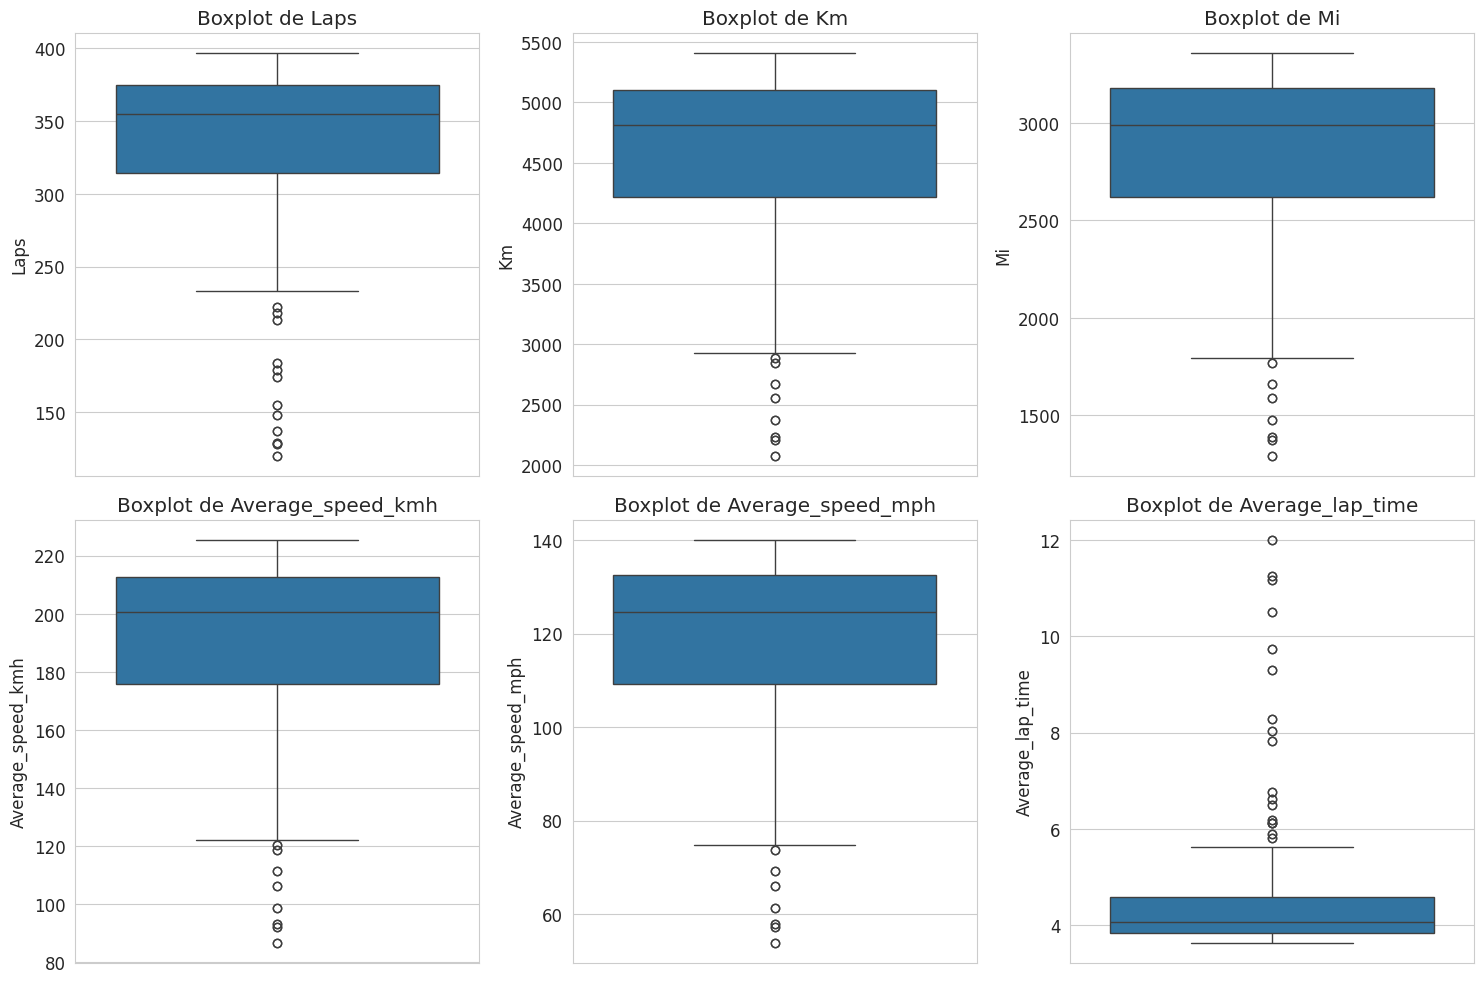

In [104]:
# Crear Bloxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

Interpretación:

Histogramas: Muestran la forma de la distribución. Average_speed_kmh tiene una distribución asimétrica positiva (aumenta con el tiempo). Laps tiene picos en ciertos valores debido a cambios en la longitud del circuito.

Boxplots: Revelan outliers. Por ejemplo, velocidades muy bajas en los primeros años, o vueltas muy altas en años con circuito más largo. Los outliers pueden ser años especiales (ej. 1930-1939) y no necesariamente errores.

**Para Regresión: Predecir Número de vueltas totales.**

*Objetivo:* `Laps_mm`

**Para Clasificación: Predecir Nacionalidad del Equipo**
*Objetivo:* `Team_nationality_LE`.

In [105]:
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Configuración de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [106]:
# =============================================================================
# ANÁLISIS INICIAL DE LAS VARIABLES OBJETIVO
# =============================================================================
print("\n===== ESTADÍSTICAS DE LAS VUELTAS (MinMax, rango 0-1) =====")
print(df_final_processed['Laps_mm'].describe())
print("Nota: El valor original mínimo es 120 vueltas y el máximo 397 vueltas.")

print("\n===== DISTRIBUCIÓN DE NACIONALIDAD DEL EQUIPO (Team_nationality_LE) =====")
print(df_final_processed['Team_nationality_LE'].value_counts().sort_index())
# Mapeo de números a países (opcional, para interpretar después)
team_nat_labels = {0: 'AUT', 1: 'DEU', 2: 'FRA', 3: 'GBR', 4: 'ITA', 5: 'JPN', 6: 'USA'}
print("\nMapeo de etiquetas:", team_nat_labels)


===== ESTADÍSTICAS DE LAS VUELTAS (MinMax, rango 0-1) =====
count    227.000000
mean       0.759729
std        0.245186
min        0.000000
25%        0.700361
50%        0.848375
75%        0.920578
max        1.000000
Name: Laps_mm, dtype: float64
Nota: El valor original mínimo es 120 vueltas y el máximo 397 vueltas.

===== DISTRIBUCIÓN DE NACIONALIDAD DEL EQUIPO (Team_nationality_LE) =====
Team_nationality_LE
0     2
1    90
2    38
3    47
4    19
5    21
6    10
Name: count, dtype: int64

Mapeo de etiquetas: {0: 'AUT', 1: 'DEU', 2: 'FRA', 3: 'GBR', 4: 'ITA', 5: 'JPN', 6: 'USA'}


In [107]:
# =============================================================================
# REGRESIÓN LINEAL (NUEVO OBJETIVO: PREDECIR VUELTAS - Laps_mm)
# =============================================================================


# -Selección de variables (EXCLUIMOS todo lo que cause fuga) ---
# Excluimos: velocidad, tiempo por vuelta, distancia (Km/Mi) y cualquier derivada.
exclude_reg = [
    'Laps_mm',                         # TARGET (lo predecimos)
    'Average_speed_kmh_mm',            # FUGA (velocidad = distancia / 24h)
    'Average_speed_mph_mm',            # FUGA
    'Average_lap_time_mm',             # FUGA (tiempo por vuelta)
    'Average_speed_kmh_std',           # Otra escala
    'Average_speed_mph_std',
    'Average_lap_time_std',
    'Laps_std', 'Km_std', 'Mi_std',
    'Km_mm', 'Mi_mm',                  # Redundantes con Laps_mm
    'Drivers_TOP', 'Team_TOP', 'Car_TOP', 'Driver_nationality_TOP',
    'Driver_nationality_FRA', 'Driver_nationality_GBR',
    'Driver_nationality_ITA', 'Driver_nationality_Other',
    'Driver_nationality_USA',
    'Team_nationality_LE'              # No queremos que la nacionalidad del equipo prediga vueltas
]

# Excluir TODAS las columnas de pilotos (Drivers_*)
drivers_cols = [col for col in df_final_processed.columns if col.startswith('Drivers_')]
exclude_reg.extend(drivers_cols)

features_reg = [col for col in df_final_processed.columns if col not in exclude_reg]
X_reg = df_final_processed[features_reg].select_dtypes(include=[np.number])
y_reg = df_final_processed['Laps_mm']

print(f"\nVariables predictoras para regresión (prediciendo vueltas): {X_reg.shape[1]}")
print("Lista completa:", X_reg.columns.tolist())



Variables predictoras para regresión (prediciendo vueltas): 14
Lista completa: ['Year', 'Class_LE', 'Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing', 'Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Other', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid', 'Tyre_LE', 'Series_LE']


In [108]:
# --- División entrenamiento/prueba y escalado ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


In [109]:
# --- Entrenamiento y evaluación ---
lr = LinearRegression()
lr.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = lr.predict(X_test_reg_scaled)

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
cv_scores = cross_val_score(lr, X_train_reg_scaled, y_train_reg, cv=5, scoring='r2')

print("\n===== RESULTADOS REGRESIÓN (VUELTAS) =====")
print(f"MSE en test: {mse:.5f}")
print(f"R² en test: {r2:.4f}")
print(f"R² medio en validación cruzada (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


===== RESULTADOS REGRESIÓN (VUELTAS) =====
MSE en test: 0.01287
R² en test: 0.7524
R² medio en validación cruzada (5 folds): 0.8357 (+/- 0.0424)


In [110]:
# --- Coeficientes (importancia) ---
coef_df = pd.DataFrame({
    'Variable': X_reg.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\nTOP 10 variables que más influyen en las vueltas:")
print(coef_df.head(10))



TOP 10 variables que más influyen en las vueltas:
                    Variable  Coeficiente
0                       Year     0.245842
1                   Class_LE     0.060709
3                 Team_Other     0.035365
5      Team_Scuderia Ferrari     0.031258
4      Team_Rothmans Porsche     0.028114
12                   Tyre_LE    -0.026540
6   Team_Toyota Gazoo Racing    -0.026162
11   Car_Toyota TS050 Hybrid     0.018322
10    Car_Porsche 919 Hybrid    -0.017579
9                  Car_Other     0.015595


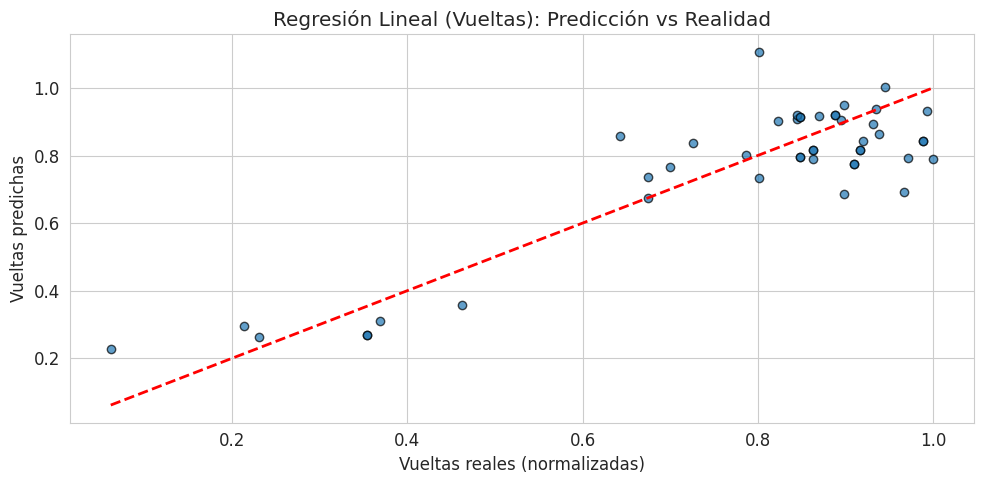

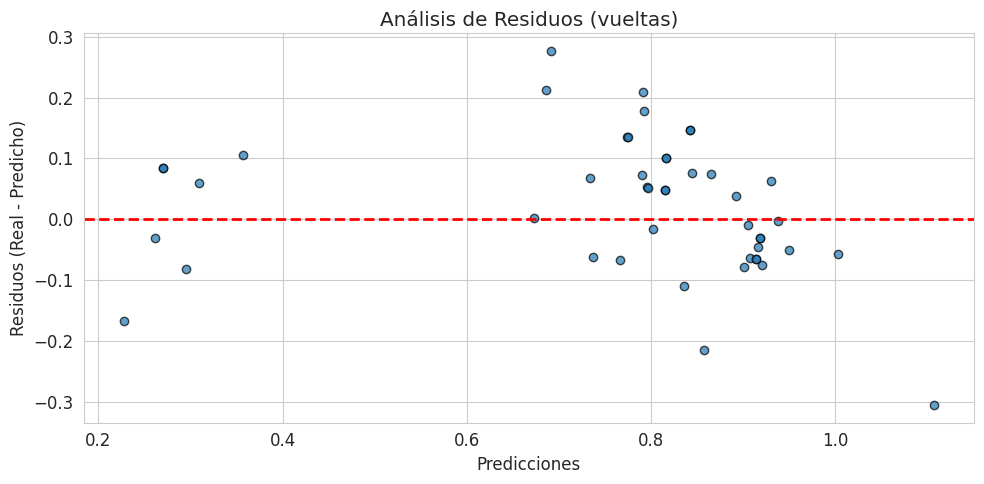


Archivos exportados para el dashboard (REGRESIÓN):
 - datos_regresion_vueltas.csv
 - coeficientes_top10_vueltas.csv


In [111]:
# --- Gráficos de diagnóstico (Regresión) ---
# Gráfico 1: Reales vs Predichos
plt.figure(figsize=(10,5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7, edgecolors='k')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Vueltas reales (normalizadas)')
plt.ylabel('Vueltas predichas')
plt.title('Regresión Lineal (Vueltas): Predicción vs Realidad')
plt.tight_layout()
plt.show()

# Gráfico 2: Residuos
residuos = y_test_reg - y_pred_reg
plt.figure(figsize=(10,5))
plt.scatter(y_pred_reg, residuos, alpha=0.7, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicciones')
plt.ylabel('Residuos (Real - Predicho)')
plt.title('Análisis de Residuos (vueltas)')
plt.tight_layout()
plt.show()

# --- 4.6 Exportar datos de regresión para el dashboard ---
# Dataset con reales y predichos
df_reg_results = X_test_reg.copy()
df_reg_results['Real'] = y_test_reg
df_reg_results['Predicho'] = y_pred_reg
df_reg_results['Residuo'] = y_test_reg - y_pred_reg
df_reg_results.to_csv('datos_regresion_vueltas.csv', index=False)

# Coeficientes Top 10
coef_export = coef_df.head(10)
coef_export.to_csv('coeficientes_top10_vueltas.csv', index=False)

print("\nArchivos exportados para el dashboard (REGRESIÓN):")
print(" - datos_regresion_vueltas.csv")
print(" - coeficientes_top10_vueltas.csv")

In [112]:
# =============================================================================
# CLASIFICACIÓN (ÁRBOL DE DECISIÓN) - Nacionalidad del Equipo
# =============================================================================

# --- Selección de variables (EXCLUIMOS equipos, coches y pilotos) ---
exclude_clf = [
    'Team_nationality_LE',             # TARGET
    'Drivers_TOP', 'Team_TOP', 'Car_TOP', 'Driver_nationality_TOP',
    'Driver_nationality_FRA', 'Driver_nationality_GBR',
    'Driver_nationality_ITA', 'Driver_nationality_Other',
    'Driver_nationality_USA',
]

# Excluir TODAS las columnas One-Hot de equipos, coches y pilotos
team_cols = [col for col in df_final_processed.columns if col.startswith('Team_')]
car_cols = [col for col in df_final_processed.columns if col.startswith('Car_')]
drivers_cols = [col for col in df_final_processed.columns if col.startswith('Drivers_')]
exclude_clf.extend(team_cols)
exclude_clf.extend(car_cols)
exclude_clf.extend(drivers_cols)

features_clf = [col for col in df_final_processed.columns if col not in exclude_clf]
X_clf = df_final_processed[features_clf].select_dtypes(include=[np.number])
y_clf = df_final_processed['Team_nationality_LE']

print(f"\nVariables predictoras para clasificación: {X_clf.shape[1]}")
print("Lista completa:", X_clf.columns.tolist())
print("\nDistribución de clases (Team_nationality_LE):")
print(y_clf.value_counts().sort_index())



Variables predictoras para clasificación: 16
Lista completa: ['Year', 'Class_LE', 'Tyre_LE', 'Series_LE', 'Laps_std', 'Km_std', 'Mi_std', 'Average_speed_kmh_std', 'Average_speed_mph_std', 'Average_lap_time_std', 'Laps_mm', 'Km_mm', 'Mi_mm', 'Average_speed_kmh_mm', 'Average_speed_mph_mm', 'Average_lap_time_mm']

Distribución de clases (Team_nationality_LE):
Team_nationality_LE
0     2
1    90
2    38
3    47
4    19
5    21
6    10
Name: count, dtype: int64


In [113]:
# --- División estratificada y escalado ---
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [114]:
# --- Entrenamiento del árbol con balanceo ---
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    criterion='gini',
    class_weight='balanced'  # Compensa el desbalance
)
dt.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = dt.predict(X_test_clf_scaled)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
print("\n===== RESULTADOS CLASIFICACIÓN =====")
print(f"Precisión global (Accuracy): {accuracy:.4f}")
print("\nReporte de clasificación (con balanceo):")
print(classification_report(y_test_clf, y_pred_clf))



===== RESULTADOS CLASIFICACIÓN =====
Precisión global (Accuracy): 0.5652

Reporte de clasificación (con balanceo):
              precision    recall  f1-score   support

           1       0.88      0.39      0.54        18
           2       0.55      0.75      0.63         8
           3       0.75      0.30      0.43        10
           4       0.57      1.00      0.73         4
           5       1.00      1.00      1.00         4
           6       0.17      1.00      0.29         2

    accuracy                           0.57        46
   macro avg       0.65      0.74      0.60        46
weighted avg       0.74      0.57      0.58        46



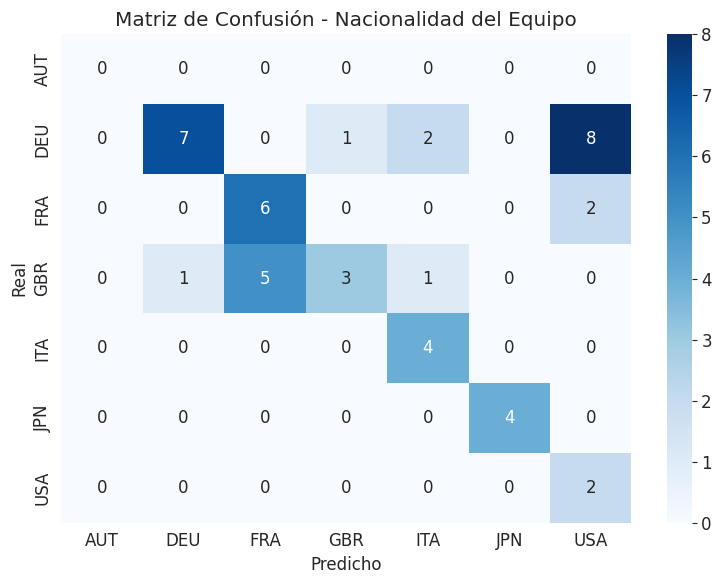

In [115]:
# --- Matriz de confusión (con nombres de países) ---
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=dt.classes_)
# Mapear números a países
etiquetas = {0: 'AUT', 1: 'DEU', 2: 'FRA', 3: 'GBR', 4: 'ITA', 5: 'JPN', 6: 'USA'}
class_names = [etiquetas.get(c, str(c)) for c in dt.classes_]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Nacionalidad del Equipo')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

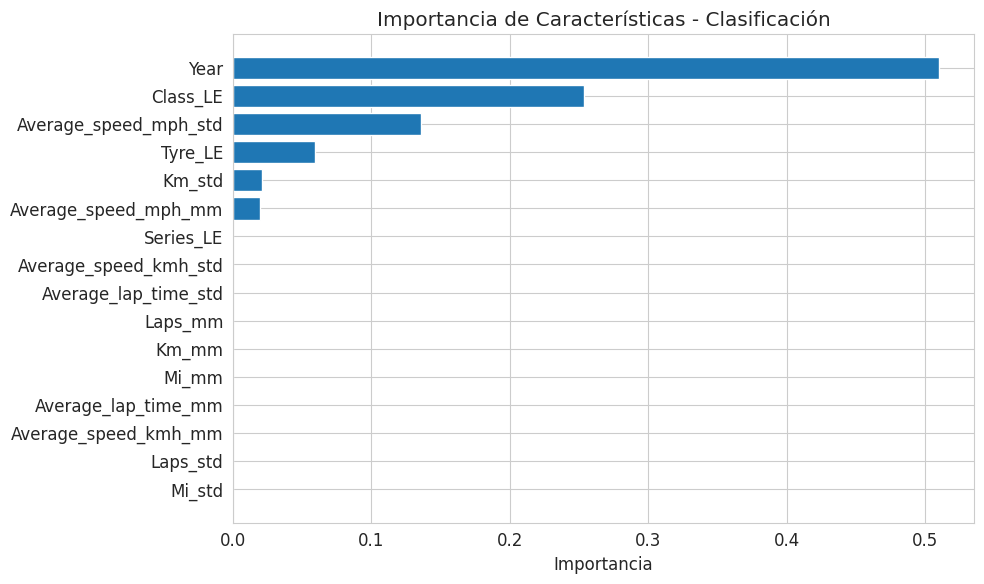

In [116]:
# --- Importancia de características ---
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [X_clf.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.title('Importancia de Características - Clasificación')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [117]:
# --- Exportar datos de clasificación para el dashboard ---
# Reales y predichos
df_clf_results = X_test_clf.copy()
df_clf_results['Real'] = y_test_clf
df_clf_results['Predicho'] = y_pred_clf
df_clf_results.to_csv('datos_clasificacion.csv', index=False)

# Importancia de características
imp_df = pd.DataFrame({
    'Variable': X_clf.columns,
    'Importancia': dt.feature_importances_
}).sort_values('Importancia', ascending=False)
imp_df.to_csv('importancia_caracteristicas.csv', index=False)

# Matriz de confusión (formato para Looker Studio)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df_reset = cm_df.reset_index().rename(columns={'index': 'Real'})
cm_df_reset.to_csv('matriz_confusion_corregida.csv', index=False)

print("\nArchivos exportados para el dashboard (CLASIFICACIÓN):")
print(" - datos_clasificacion.csv")
print(" - importancia_caracteristicas.csv")
print(" - matriz_confusion_corregida.csv")


Archivos exportados para el dashboard (CLASIFICACIÓN):
 - datos_clasificacion.csv
 - importancia_caracteristicas.csv
 - matriz_confusion_corregida.csv


In [118]:
# =============================================================================
# CLUSTERING (K-MEANS) - SEGMENTACIÓN HISTÓRICA
# =============================================================================

# --- Selección de variables para clustering ---
features_cluster = [
    'Year', 'Class_LE', 'Tyre_LE', 'Series_LE',
    'Laps_mm', 'Km_mm', 'Average_speed_kmh_mm', 'Average_lap_time_mm'
]
X_cluster = df_final_processed[features_cluster].copy()

# Estandarizar (necesario para K-means)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

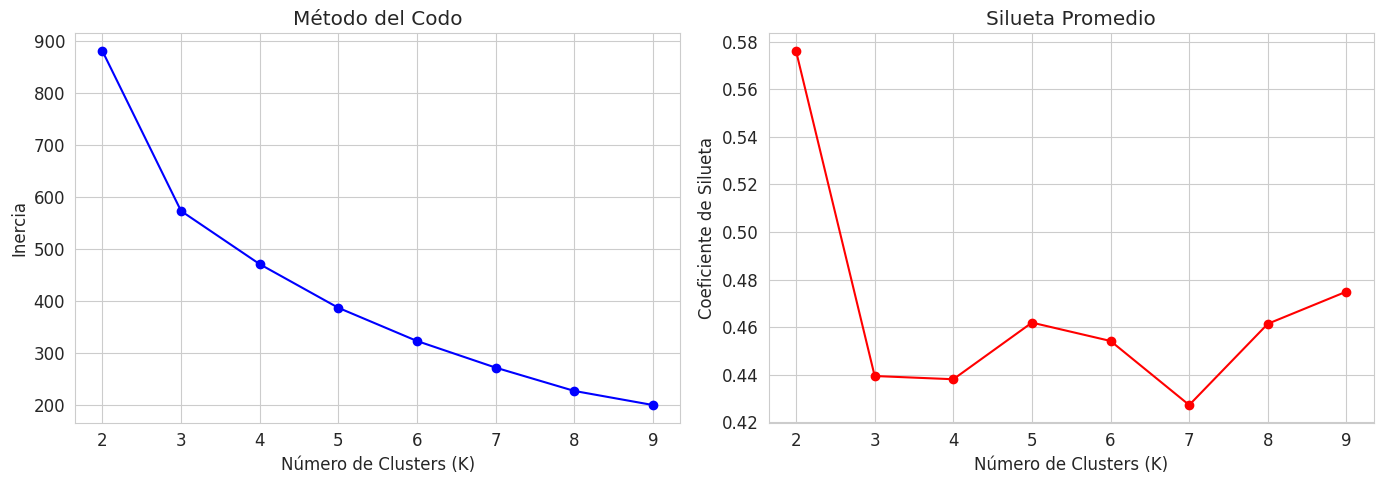

In [119]:
# --- Método del codo y silueta para elegir K ---
inertias = []
silhouettes = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Gráficos de evaluación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.set_title('Silueta Promedio')
plt.tight_layout()
plt.show()

In [120]:
# --- Ajuste final con K=3 (según análisis) ---
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Tabla de centroides (perfil de cada cluster)
centroids_df = pd.DataFrame(
    scaler_cluster.inverse_transform(kmeans.cluster_centers_),
    columns=features_cluster
)
centroids_df['Cluster'] = range(k_optimo)
centroids_df['Nº Carreras'] = df['Cluster'].value_counts().sort_index().values

print("\n===== TABLA DE CENTROIDES (PERFIL DE CADA CLUSTER) =====")
print(centroids_df.round(2))


===== TABLA DE CENTROIDES (PERFIL DE CADA CLUSTER) =====
      Year  Class_LE  Tyre_LE  Series_LE  Laps_mm  Km_mm  \
0  1931.76      1.65     3.12       7.00     0.25   0.22   
1  1971.57     10.93     2.67      10.63     0.78   0.74   
2  1999.28     10.12     5.53       5.06     0.89   0.87   

   Average_speed_kmh_mm  Average_lap_time_mm  Cluster  Nº Carreras  
0                  0.22                 0.54        0           34  
1                  0.74                 0.08        1           67  
2                  0.87                 0.04        2          126  


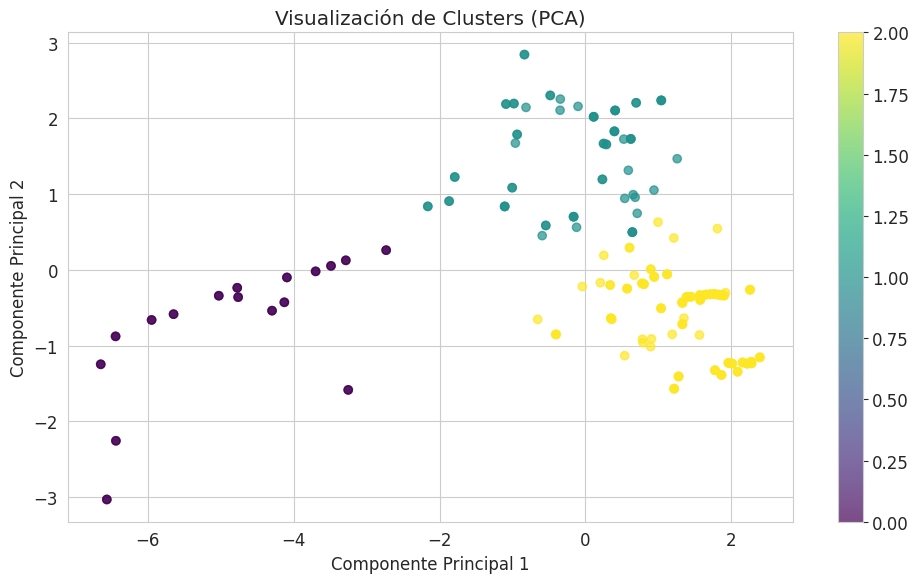

In [121]:
# --- Visualización de clusters con PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualización de Clusters (PCA)')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

In [123]:
# --- Exportar dataset con clusters para el dashboard ---
df.to_csv('LeMans_con_clusters.csv', index=False)
print("\nArchivo exportado para el dashboard (CLUSTERING):")
print(" - LeMans_con_clusters.csv")


Archivo exportado para el dashboard (CLUSTERING):
 - LeMans_con_clusters.csv


In [124]:
# =============================================================================
# RESUMEN FINAL
# =============================================================================
print("\n" + "="*60)
print("RESUMEN DE ARCHIVOS EXPORTADOS PARA LOOKER STUDIO")
print("="*60)
print("""
Archivos listos para subir a Google Drive y conectar a Looker Studio:

1. datos_regresion_vueltas.csv       → (Real, Predicho, Residuo de vueltas)
2. coeficientes_top10_vueltas.csv    → (Top 10 variables que influyen en vueltas)
3. datos_clasificacion.csv           → (Real, Predicho de nacionalidad del equipo)
4. importancia_caracteristicas.csv   → (Importancia de variables del árbol)
5. matriz_confusion_corregida.csv    → (Matriz de confusión con nombres de países)
6. LeMans_con_clusters.csv           → (Dataset completo con Cluster, PC1, PC2)
""")


RESUMEN DE ARCHIVOS EXPORTADOS PARA LOOKER STUDIO

Archivos listos para subir a Google Drive y conectar a Looker Studio:

1. datos_regresion_vueltas.csv       → (Real, Predicho, Residuo de vueltas)
2. coeficientes_top10_vueltas.csv    → (Top 10 variables que influyen en vueltas)
3. datos_clasificacion.csv           → (Real, Predicho de nacionalidad del equipo)
4. importancia_caracteristicas.csv   → (Importancia de variables del árbol)
5. matriz_confusion_corregida.csv    → (Matriz de confusión con nombres de países)
6. LeMans_con_clusters.csv           → (Dataset completo con Cluster, PC1, PC2)



Link Repositorio Github: https://github.com/claudrojasp-cmyk/mineria_datos_clases/tree/main

Link DataStudio: https://datastudio.google.com/reporting/576d6da0-4bb0-4ef6-9bc5-dd02f4072ef7